In [ ]:
#  import the necessary libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split


# Data pipeline

``` 
Input → normalize → reshape
```

In [ ]:
#  now we will load the dataset and split it into training and testing sets
minst = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = minst.load_data()


In [ ]:
x_train


array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [ ]:
y_train.shape


(60000,)

In [ ]:
x_train.shape


(60000, 28, 28)

Text(0.5, 1.0, 'Label: 5')

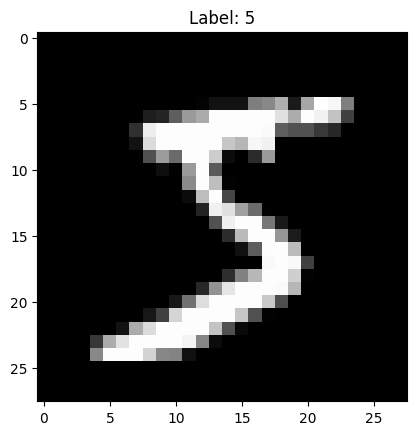

In [ ]:
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")


In [ ]:
#  now  let Normalize the data (scale the pixel values to be between 0 and 1)   of x train and y train     before feeding it into the model
x_train = x_train / 255.0
x_test = x_test / 255.0

#  because the pixel values are now scaled between 0 and 1, the model will train faster and more efficiently  and data  range  is 255   so when  we divide by 255 we get values between 0 and 1 which is good for training the model.


# 5 Reshape for CNN

CNN expects a channel dimension:
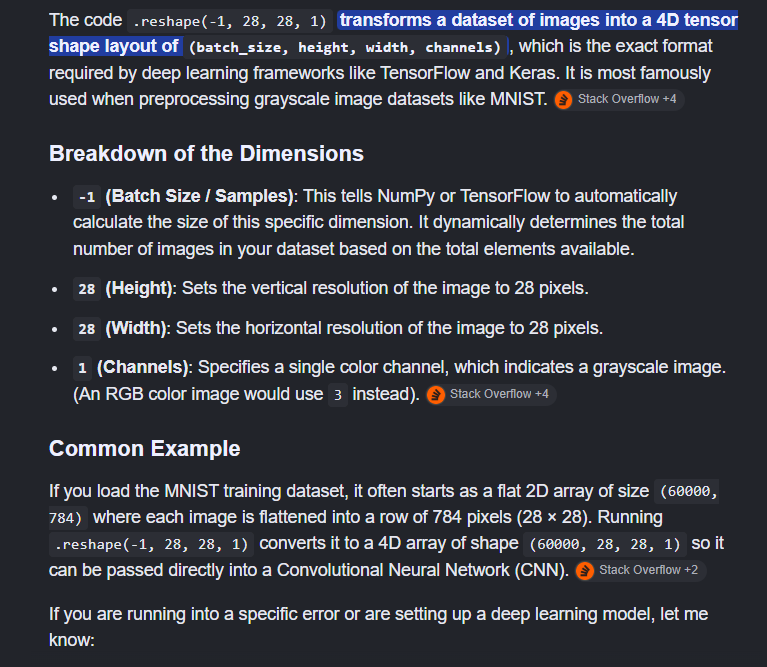

In [ ]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


In [ ]:
x_train[0]  # first image after reshaping


array([[[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        

# 6. Build CNN Model

Now the real deep learning part.
```CNN intuition
Conv layer = feature detector (edges, shapes)
Pooling = compression
Dense = decision maker
```
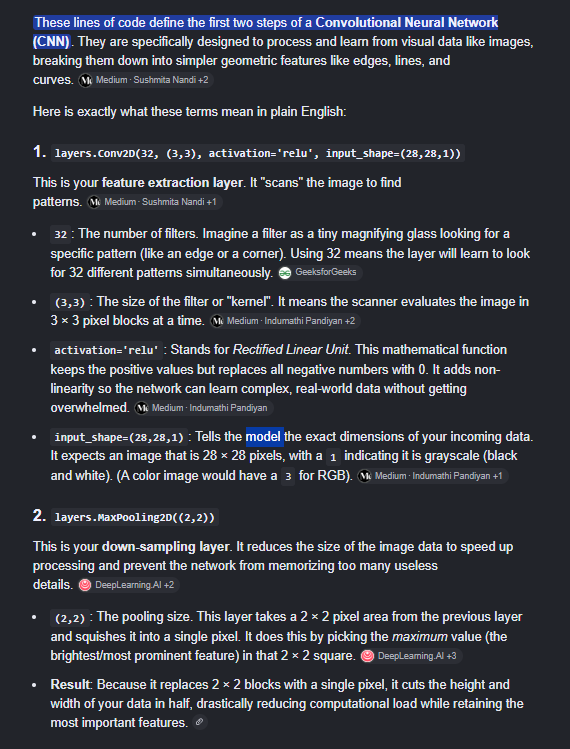

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    #  second convolutional layer with 64 filters and a kernel size of 3x3, followed by another max pooling layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # flatten the output from the convolutional layers and add a fully connected layer with 64 units and a ReLU activation function, followed by an output layer with 10 units (one for each digit) and a softmax activation function.
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    # fully connected layer with 64 units and a ReLU activation function
    layers.Dense(64, activation='relu'),
    # output layer with 10 units (one for each digit) and a softmax activation function
    # Output layer (10 classes: 0–9)
    layers.Dense(10, activation='softmax')
])


c:\Users\Hashir\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 # 7 Compile Model

```This defines: ```

loss function (error)
optimizer (learning method)
metric (accuracy)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


# 8 Train Model
```
Training logic
Forward pass → prediction
Loss calculation → error
Backpropagation → weight update 
 
 ```

In [ ]:
history = model.fit(x_train, y_train, epochs=10,
                    validation_data=(x_test, y_test))


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9533 - loss: 0.1534 - val_accuracy: 0.9777 - val_loss: 0.0701
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9849 - loss: 0.0484 - val_accuracy: 0.9877 - val_loss: 0.0391
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - accuracy: 0.9894 - loss: 0.0337 - val_accuracy: 0.9905 - val_loss: 0.0311
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9918 - loss: 0.0261 - val_accuracy: 0.9901 - val_loss: 0.0349
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.9932 - loss: 0.0211 - val_accuracy: 0.9886 - val_loss: 0.0372
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9942 - loss: 0.0171 - val_accuracy: 0.9877 - val_loss: 0.0455
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9959 - loss: 0.0134 - val_accuracy: 0.9882 - val_loss: 0.0418
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9958 -

# 9 Check Performance

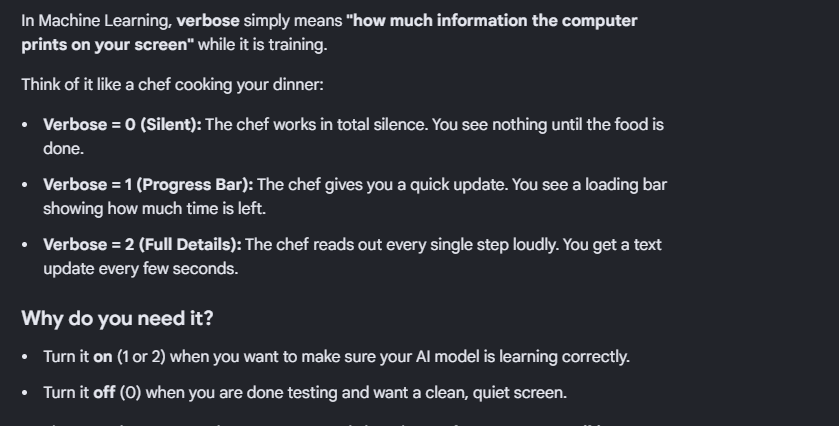

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)


313/313 - 3s - 9ms/step - accuracy: 0.9910 - loss: 0.0368


In [ ]:
print(f"Test accuracy: {test_acc}")
print(f"Test loss: {test_loss}")


Test accuracy: 0.9909999966621399
Test loss: 0.036751873791217804


# 10 Visualize Training

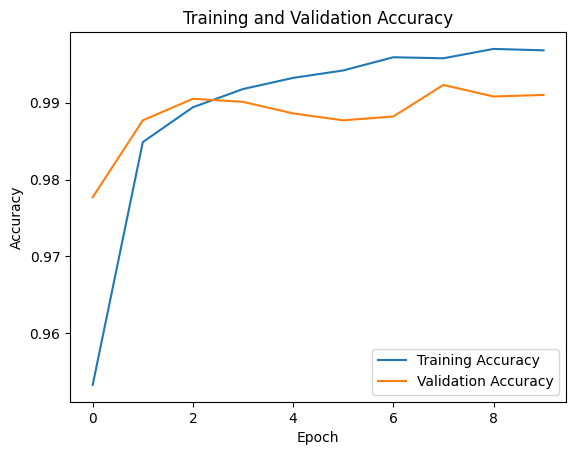

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()


# 11. Make Predictions

In [ ]:
prediction = model.predict(x_test)
predicted_labels = np.argmax(prediction, axis=1)
print(predicted_labels[:10])  # Print the first 10 predicted labels


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
[7 2 1 0 4 1 4 9 5 9]


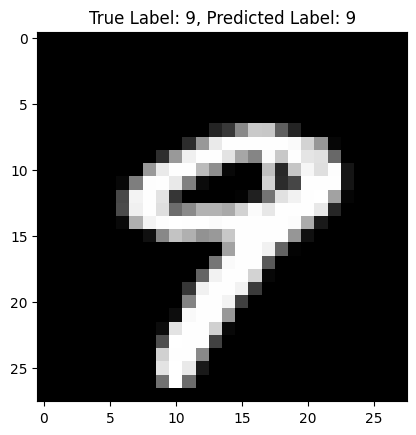

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Predicted digit: 9


In [ ]:
index = 9  # Change this index to view different test images


plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
plt.title(f"True Label: {y_test[index]}, Predicted Label: {predicted_labels}")
plt.show()


prediction = model.predict(x_test[index].reshape(1, 28, 28, 1))
predicted_labels = np.argmax(prediction)

print("Predicted digit:", np.argmax(prediction))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


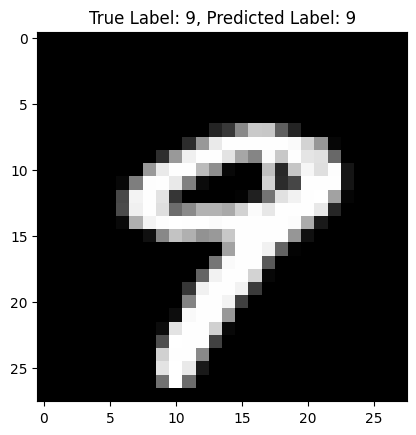

Predicted digit: 9


In [ ]:
index = 9  # change image

prediction = model.predict(x_test[index].reshape(1, 28, 28, 1))
predicted_labels = np.argmax(prediction)

plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
plt.title(f"True Label: {y_test[index]}, Predicted Label: {predicted_labels}")
plt.show()

print("Predicted digit:", predicted_labels)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


Predicted digit: 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Predicted digit: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Predicted digit: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted digit: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Predicted digit: 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Predicted digit: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Predicted digit: 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Predicted digit: 9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted digit: 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Predicted digit: 9


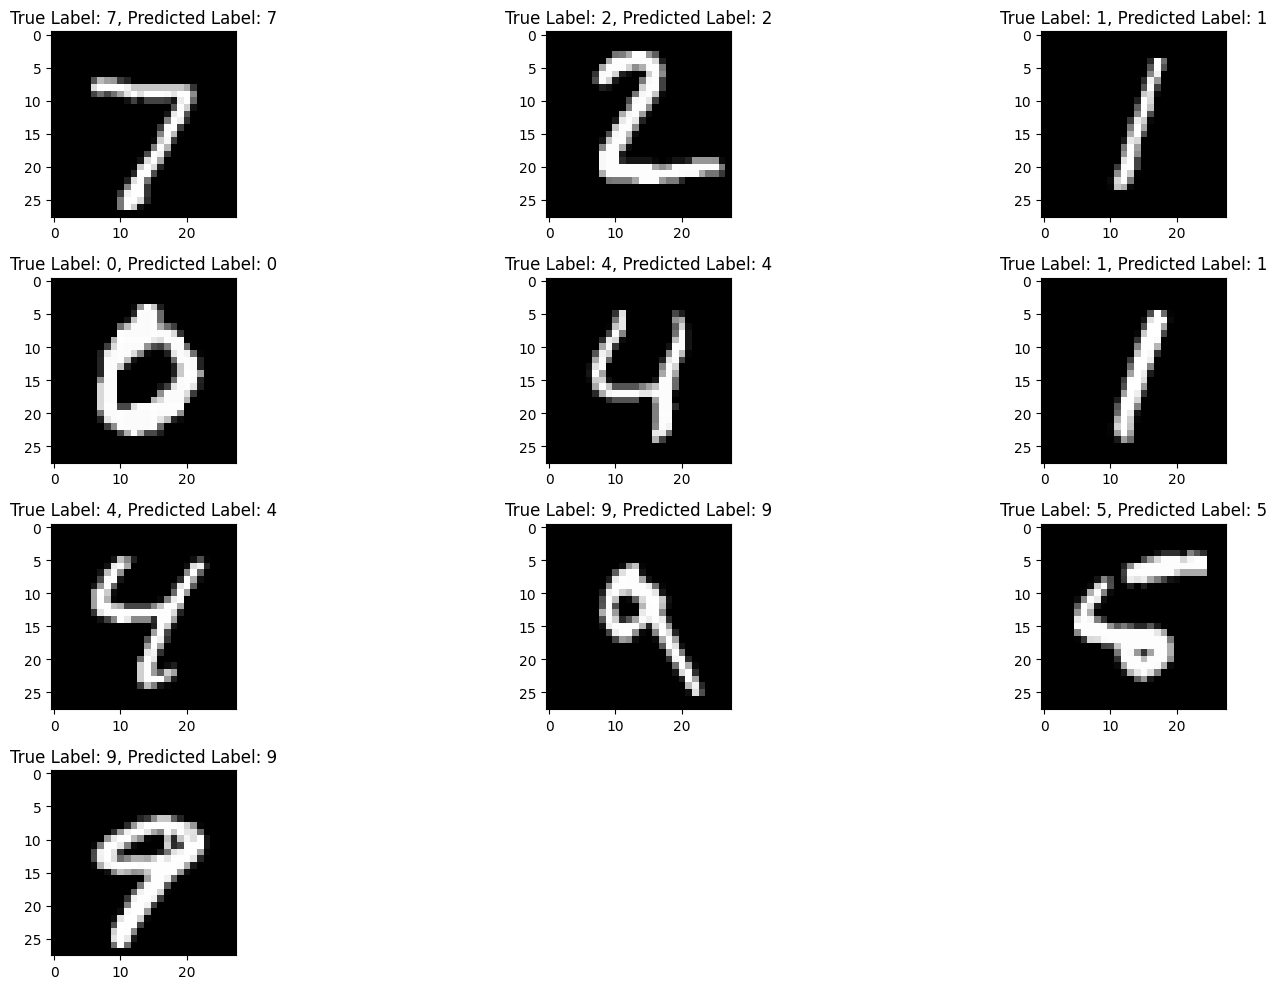

In [ ]:
plt.figure(figsize=(15, 10))

for index in range(10):
    prediction = model.predict(x_test[index].reshape(1, 28, 28, 1))
    predicted_labels = np.argmax(prediction)

    plt.subplot(4, 3, index + 1)
    plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
    plt.tight_layout()
    plt.title(
        f"True Label: {y_test[index]}, Predicted Label: {predicted_labels}")

    print("Predicted digit:", predicted_labels)


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 279,968 (1.07 MB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 186,646 (729.09 KB)

In [ ]:
prediction = model.predict(x_test)
predicted_labels = np.argmax(prediction, axis=1)
confusion_matrix = tf.math.confusion_matrix(y_test, predicted_labels)
confusion_matrix


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 971,    1,    1,    0,    3,    1,    1,    2,    0,    0],
       [   0, 1134,    0,    0,    0,    0,    0,    0,    1,    0],
       [   0,    0, 1028,    0,    0,    0,    1,    3,    0,    0],
       [   0,    0,    1, 1006,    0,    3,    0,    0,    0,    0],
       [   0,    0,    0,    0,  979,    0,    1,    0,    0,    2],
       [   0,    0,    0,    4,    0,  885,    2,    0,    1,    0],
       [   2,    2,    0,    0,    5,    2,  947,    0,    0,    0],
       [   0,    2,    4,    1,    0,    0,    0, 1019,    2,    0],
       [   1,    1,    1,    1,    0,    2,    1,    0,  966,    1],
       [   2,    1,    1,    1,   13,    7,    0,    3,    6,  975]],
      dtype=int32)>

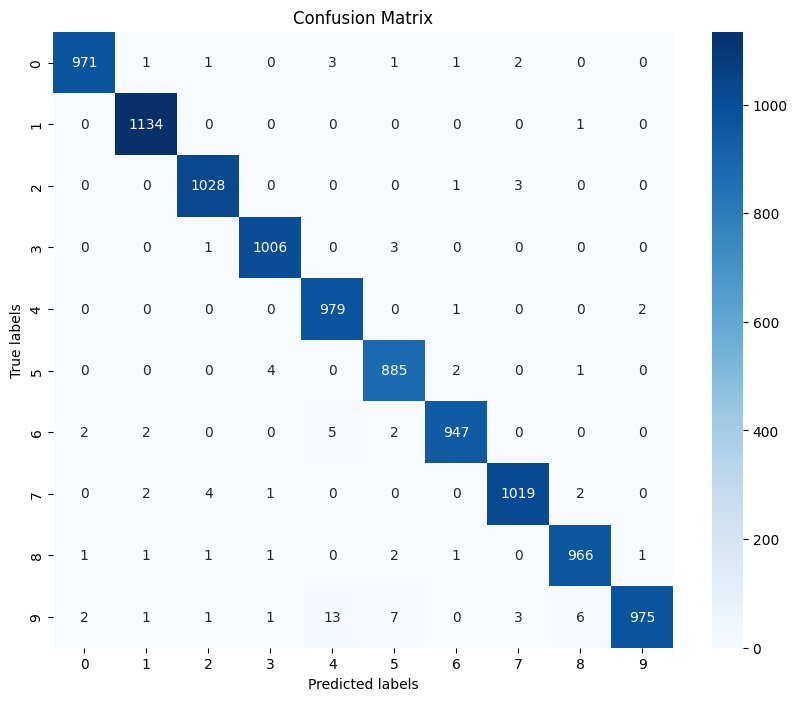

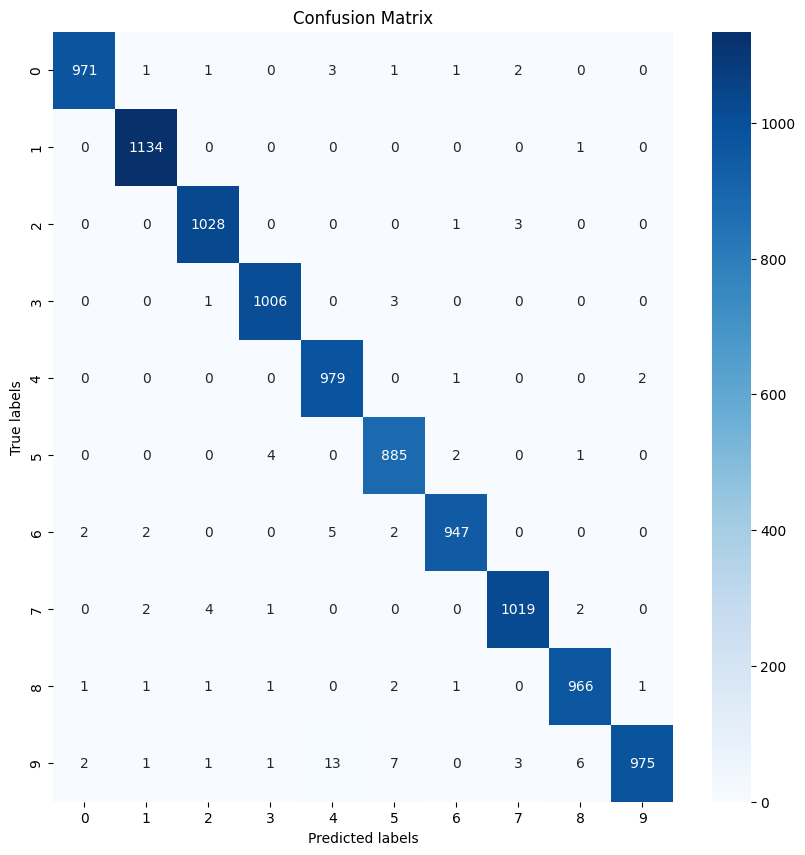

In [57]:
import seaborn as sns
plt.figure(figsize=(10, 8))
fig = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
fig.set(xlabel="Predicted Label", ylabel="True Label", title="Confusion Matrix ")
# labels, title and ticks
fig.set_xlabel('Predicted labels')
fig.set_ylabel('True labels')
fig.set_title('Confusion Matrix')
plt.figure(figsize=(10, 8))
fig = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
fig.set(xlabel="Predicted Label", ylabel="True Label", title="Confusion Matrix ")
fig.set_xlabel('Predicted labels')
fig.set_ylabel('True labels')
fig.set_title('Confusion Matrix')

class_names = [str(i) for i in range(10)]
fig.xaxis.set_ticklabels(class_names)
fig.yaxis.set_ticklabels(class_names)

fig.figure.set_size_inches(10, 10)
fig.yaxis.set_ticklabels(class_names)
fig.figure.set_size_inches(10, 10)
